<div style="background: linear-gradient(135deg, #fceff9, #e0f7fa); padding:40px; border-radius:20px; text-align:center; border:1px solid #dcdcdc;">

<h1 style="color:#6a5acd; font-size:40px; margin-bottom:10px;">
📊 Campaña de Marketing Bancario
</h1>

<h3 style="color:#8e7cc3; margin-top:0;">
Modelo de Clasificación para Depósitos a Largo Plazo
</h3>

<hr style="border: none; height: 2px; background-color: #d1c4e9; margin: 20px 0;">

<p style="font-size:18px; color:#444;">
💡 <b>Análisis Exploratorio de Datos (EDA)</b><br>
🤖 <b>Modelado con Regresión Logística</b><br>
📈 <b>Optimización del Modelo</b>
</p>

<br>

<p style="font-size:16px; color:#555;">
👩‍💻 <b>Estudiante:</b> Natalia Bayona <br>
📅 <b>Fecha:</b> 2026 <br>
🏫 <b>Proyecto académico</b>
</p>

<br>

<p style="font-size:14px; color:#888;">
✨ “Los datos cuentan historias, el análisis toma decisiones.”
</p>

</div>

Campaña de Marketing Bancario
Comprensión empresarial

Los depósitos a largo plazo permiten a los bancos retener dinero durante un período de tiempo específico, lo que permite al banco utilizar ese dinero para mejorar sus inversiones. Las campañas de marketing de este producto se basan en llamadas telefónicas. Si un usuario no se encuentra disponible en un momento dado, entonces se le volverá a llamar de nuevo en otro momento.

Descripción del problema

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

Para abordar este problema crearemos un algoritmo de clasificación que ayude a predecir si un cliente contratará o no un depósito a largo plazo.

Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre bank-marketing-campaign-data.csv, y puedes cargarlo en el código directamente desde el siguiente enlace:

https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv
O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:


age. Edad del cliente (numérico)

job. Tipo de trabajo (categórico)

marital. Estado civil (categórico)

education. Nivel de educación (categórico)

default. ¿Tiene crédito actualmente? (categórico)

housing. ¿Tiene un préstamo de vivienda? (categórico)

loan. ¿Tiene un préstamo personal? (categórico)

contact. Tipo de comunicación de contacto (categórico)

month. Último mes en el que se le ha contactado (categórico)

day_of_week. Último día en el que se le ha contactado (categórico)

duration. Duración del contacto previo en segundos (numérico)

campaign. Número de contactos realizados durante esta campaña al cliente (numérico)

pdays. Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico)

previous. Número de contactos realizados durante la campaña anterior al cliente (numérico)

poutcome. Resultado de la campaña de marketing anterior (categórico)

emp.var.rate. Tasa de variación del empleo. Indicador trimestral (numérico)

cons.price.idx. Índice de precios al consumidor. Indicador mensual (numérico)

cons.conf.idx. Índice de confianza del consumidor. Indicador mensual (numérico)

euribor3m. Tasa EURIBOR 3 meses. Indicador diario (numérico)

nr.employed. Número de empleados. Indicador trimestral (numérico)

y. TARGET. El cliente contrata un depósito a largo plazo o no (categórico)

Paso 2: Realiza un EDA completo
Este segundo paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.

Paso 3: Construye un modelo de regresión logística
No es necesario que optimices los hiperparámetros. Comienza utilizando una definición por defecto y mejórala en el paso siguiente.

Paso 4: Optimiza el modelo anterior
Después de entrenar el modelo, si los resultados no son satisfactorios, optimízalo empleando alguna de las técnicas vistas anteriormente.

In [70]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [71]:
total_data = pd.read_csv("../data/raw/bank-marketing-campaign-data.csv", sep=";")


In [72]:
total_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [73]:
total_data.shape

(41188, 21)

In [74]:
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


El conjunto de datos contiene un número considerable de registros y variables, lo que permite realizar un análisis robusto del comportamiento de los clientes frente a la campaña de marketing.

In [75]:
total_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [76]:
total_data.select_dtypes(include=['object']).columns

C:\Users\nata1\AppData\Local\Temp\ipykernel_20268\745359477.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  total_data.select_dtypes(include=['object']).columns


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')

Se identifican variables tanto numéricas como categóricas, lo que indica la necesidad de aplicar técnicas de codificación antes de entrenar modelos de machine learning.

In [77]:
total_data.dtypes.value_counts()

str        11
int64       5
float64     5
Name: count, dtype: int64

Predominan las variables categóricas, lo que sugiere que el comportamiento del cliente está fuertemente influenciado por características cualitativas.

In [78]:
total_data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [79]:
total_data.isna().sum().sum()

np.int64(0)

In [80]:
total_data.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [81]:
(total_data.isna().sum() / len(total_data) * 100).sort_values(ascending=False)

age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64

Text(0, 0.5, 'Sample Number')

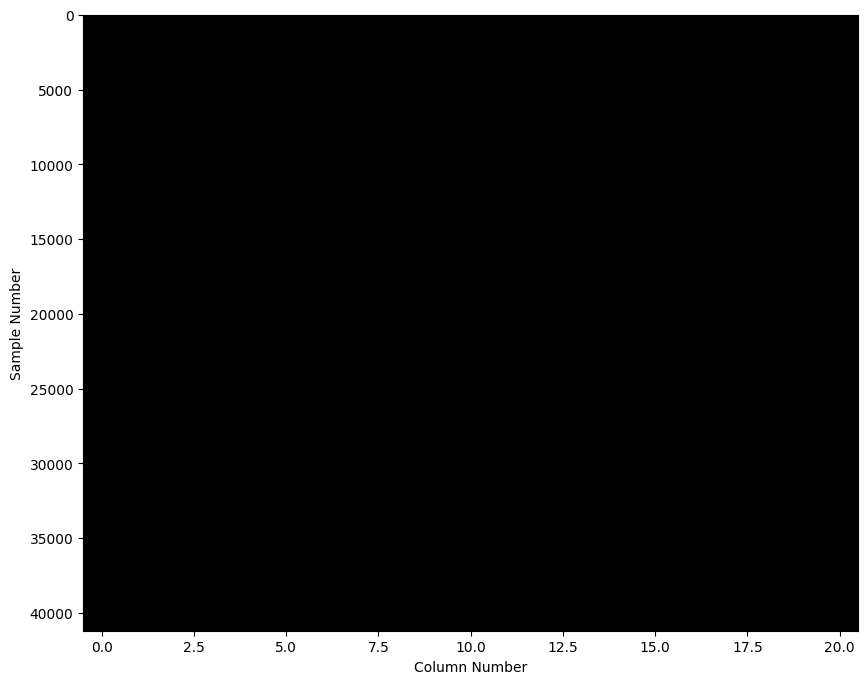

In [82]:
plt.figure(figsize=(10, 8))
plt.imshow(total_data.isna(), aspect="auto", interpolation="nearest", cmap="gray")
plt.xlabel("Column Number")
plt.ylabel("Sample Number")

El dataset presenta una cantidad nula de valores faltantes, lo que indica una buena calidad de los datos y elimina la necesidad de aplicar técnicas de imputación.

In [83]:
total_data["y"].value_counts()
total_data["y"].value_counts(normalize=True) * 100

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

La variable objetivo presenta un fuerte desbalance, donde la mayoría de los clientes no contratan el depósito a largo plazo. Esto puede afectar el rendimiento del modelo, ya que podría sesgarse hacia la clase mayoritaria.

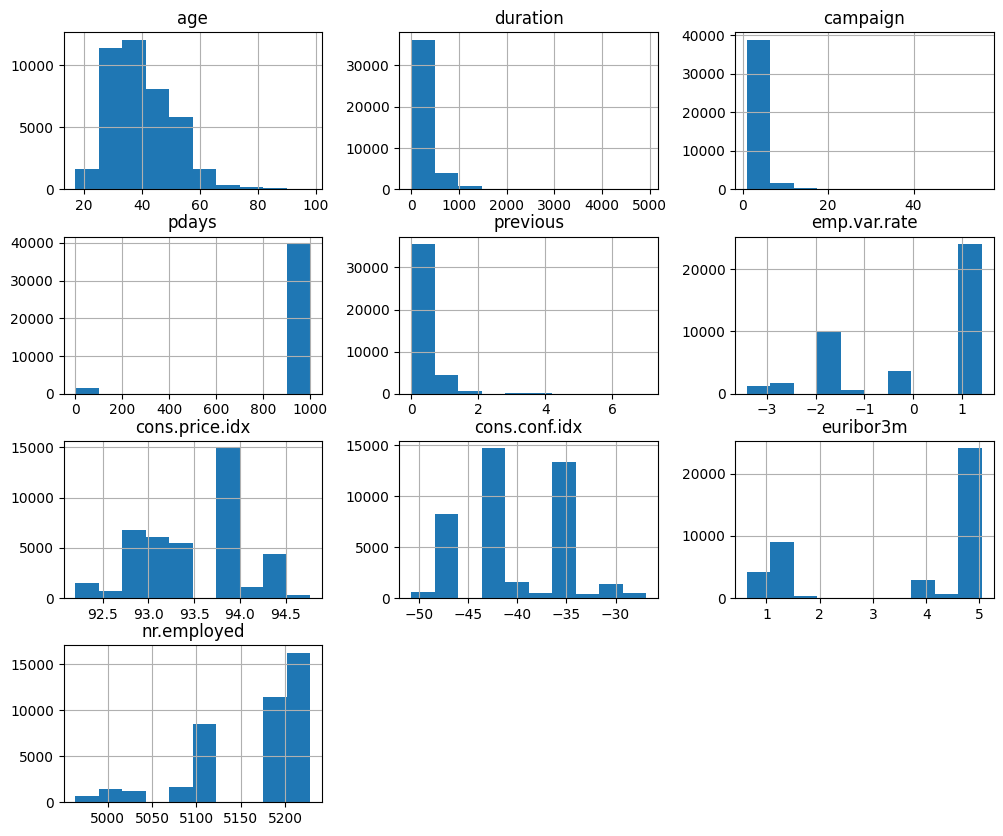

In [84]:
total_data.hist(figsize=(12,10))
plt.show()

A partir de los histogramas se observa que las variables numéricas presentan diferentes tipos de distribución, en su mayoría con sesgos hacia valores específicos, por lo que no siguen una distribución normal.

Asimismo, se identifican posibles valores atípicos en algunas variables, lo que podría influir en el comportamiento del modelo.

Estas características sugieren la posible necesidad de aplicar transformaciones o escalado en etapas posteriores del análisis.

C:\Users\nata1\AppData\Local\Temp\ipykernel_20268\892134255.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = total_data.select_dtypes(include="object").columns


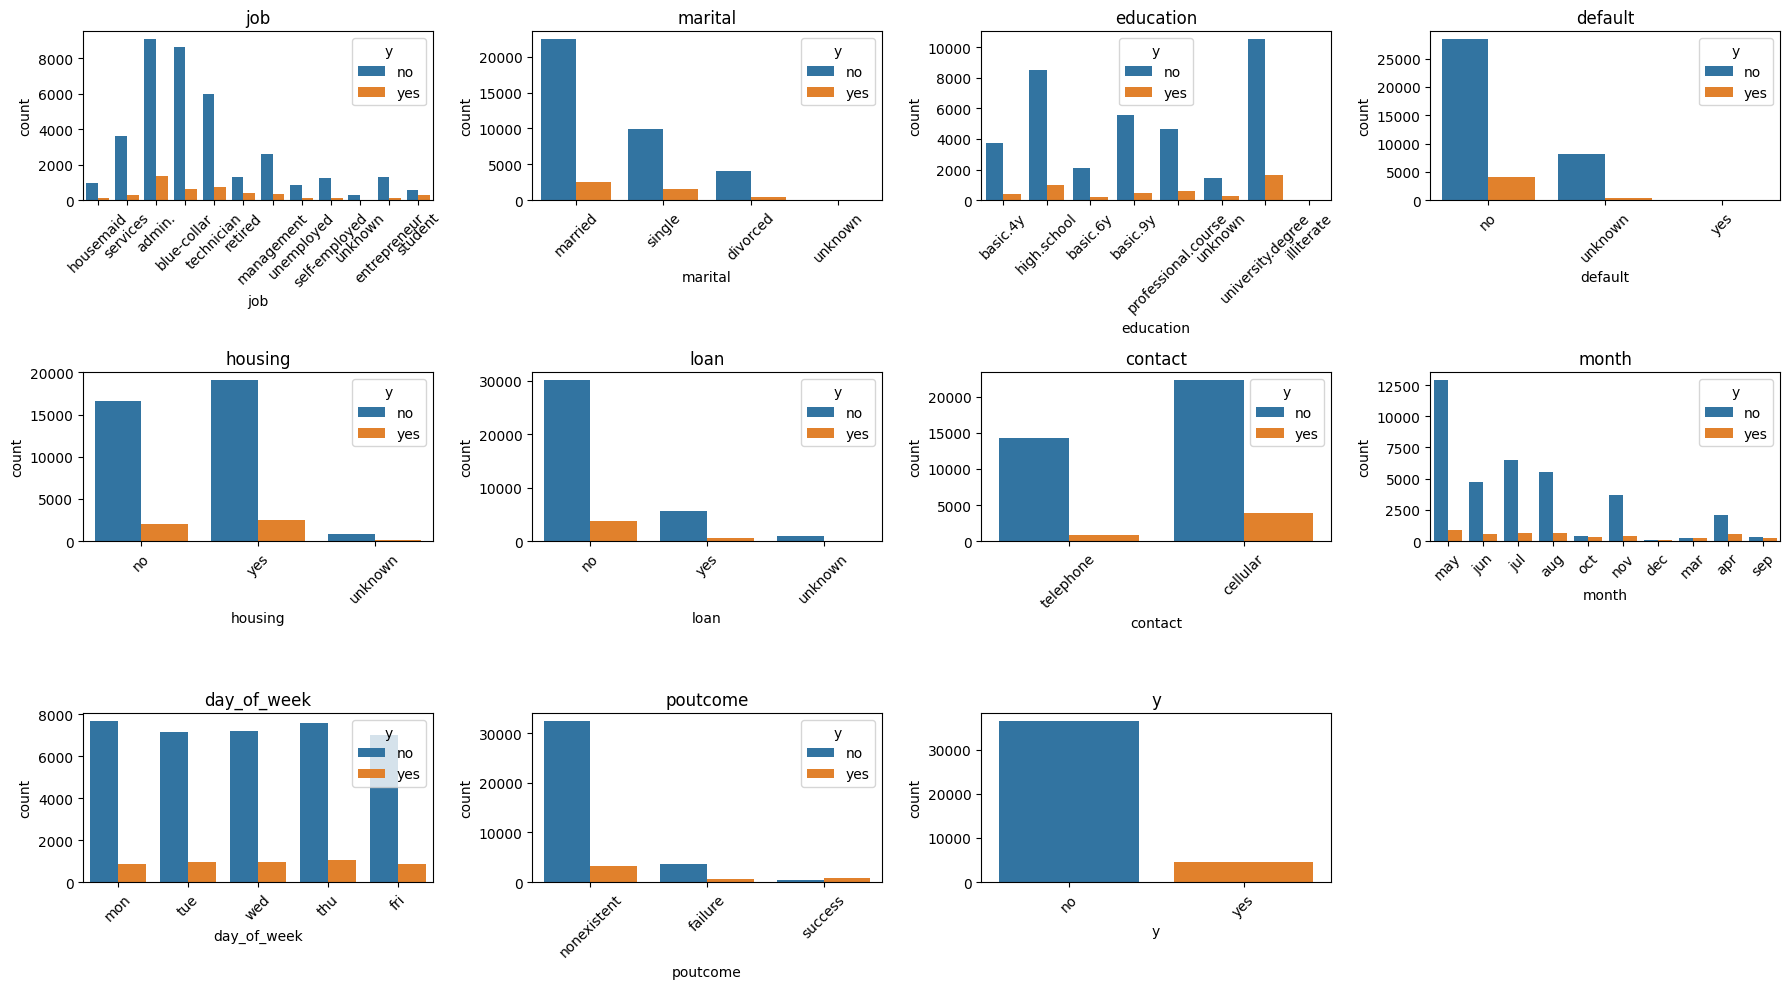

In [85]:
cat_cols = total_data.select_dtypes(include="object").columns

fig, axis = plt.subplots(3, 4, figsize=(18, 10))
axis = axis.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=total_data, x=col, hue="y", ax=axis[i])
    axis[i].set_title(col)
    axis[i].tick_params(axis='x', rotation=45)

# eliminar espacios vacíos
for j in range(i+1, len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

Se observa que algunas categorías son mucho más frecuentes que otras, lo que indica una distribución desigual entre los grupos. Además, la presencia de valores como "unknown" sugiere posibles limitaciones en la recolección de datos.

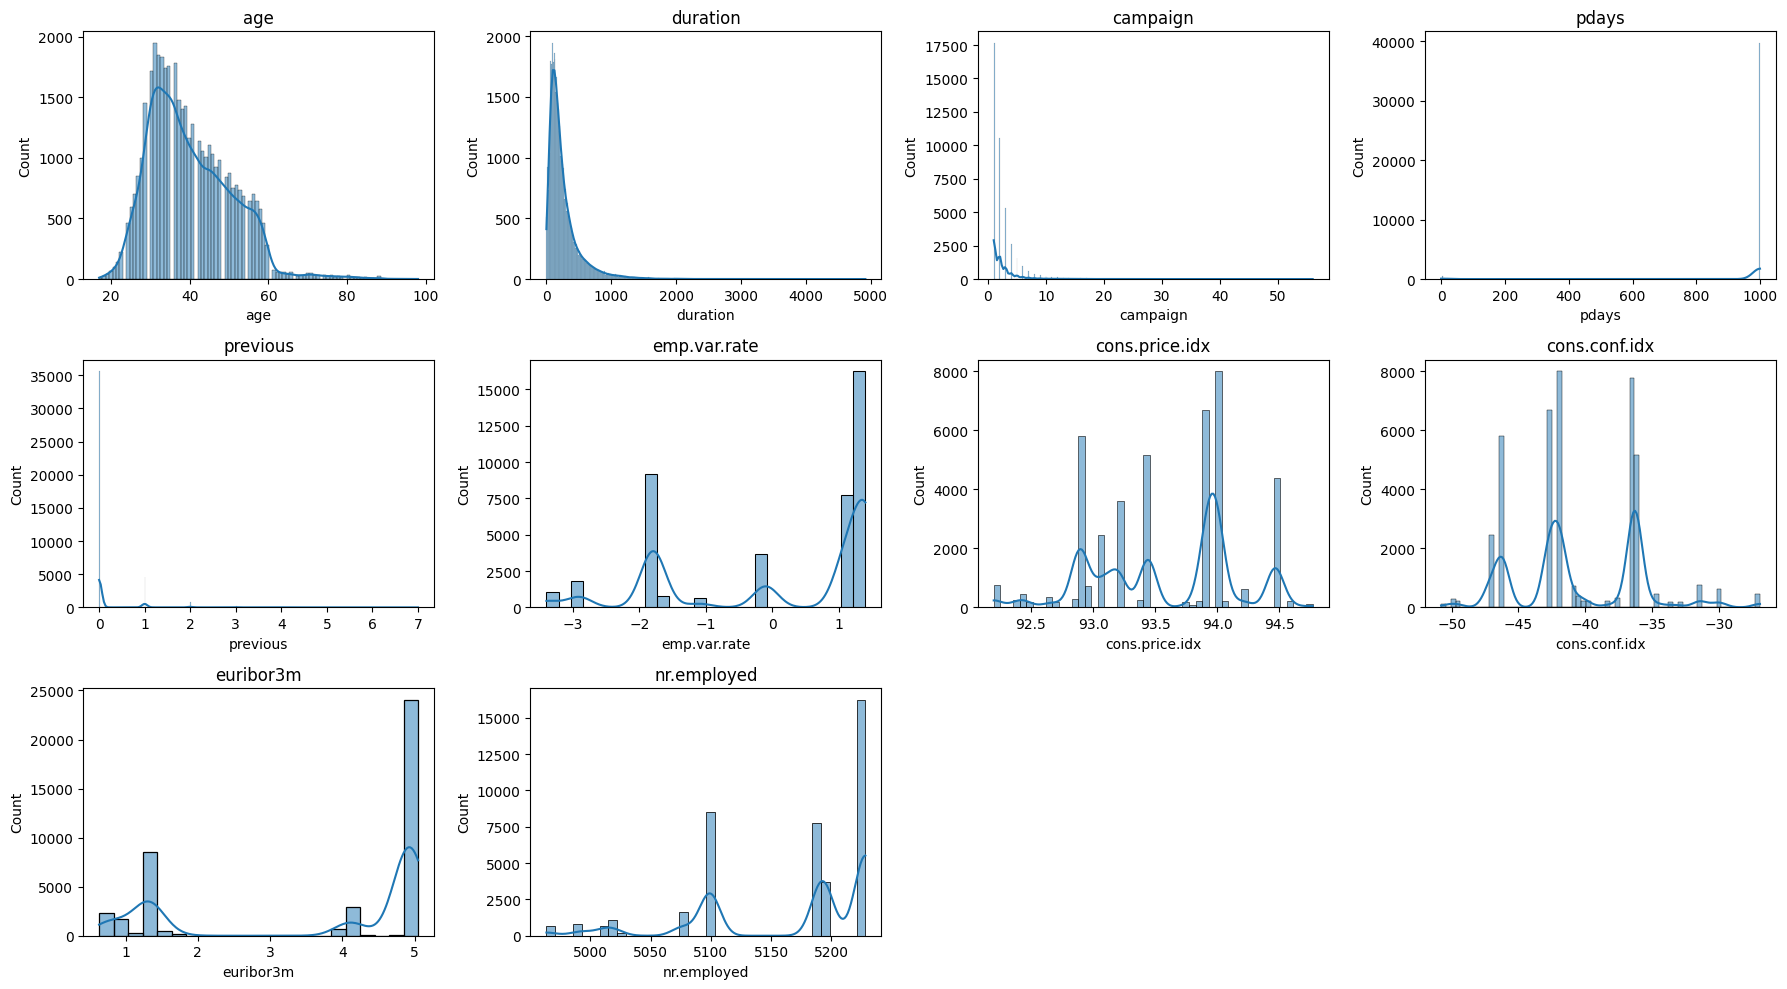

In [86]:
num_cols = total_data.select_dtypes(include=["int64", "float64"]).columns

fig, axis = plt.subplots(3, 4, figsize=(18, 10))
axis = axis.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(total_data[col], ax=axis[i], kde=True)
    axis[i].set_title(col)

for j in range(i+1, len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

Las variables numéricas presentan distribuciones variadas, algunas con sesgo hacia ciertos valores y posibles outliers. Esto indica que podría ser necesario aplicar transformaciones o normalización en etapas posteriores.

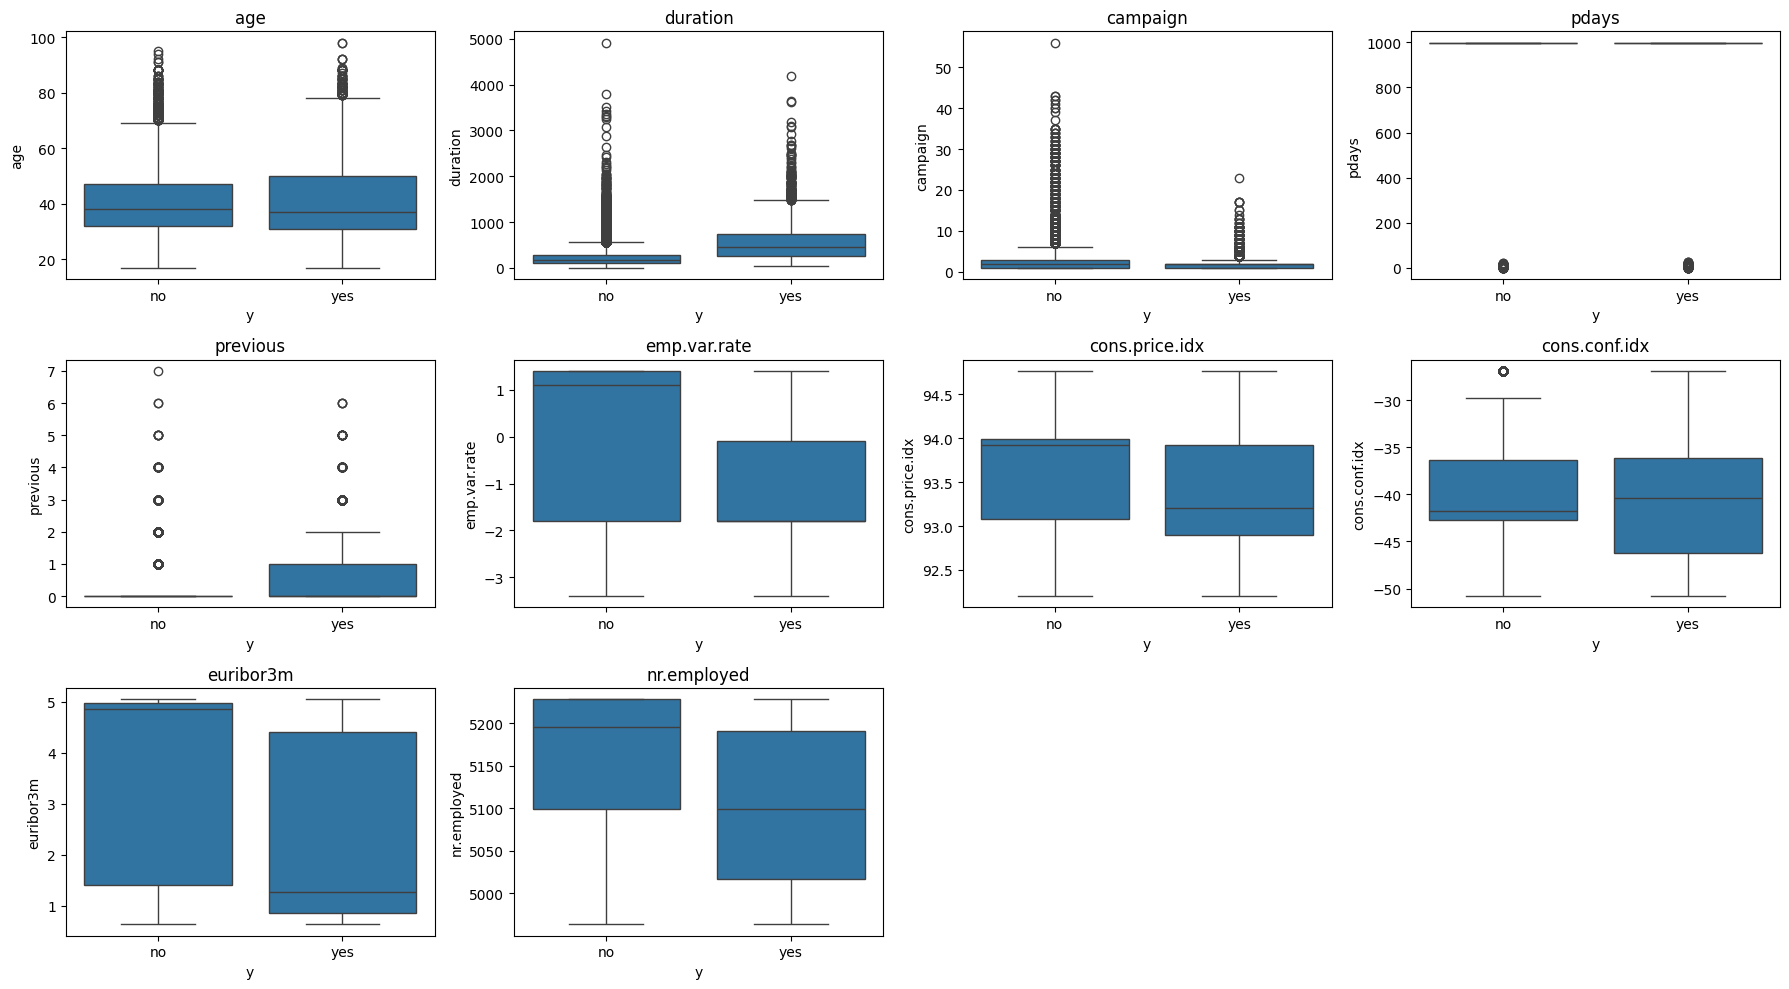

In [87]:
fig, axis = plt.subplots(3, 4, figsize=(18, 10))
axis = axis.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=total_data, x="y", y=col, ax=axis[i])
    axis[i].set_title(col)

for j in range(i+1, len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

Se observan diferencias en la distribución de algunas variables numéricas entre los clientes que contratan y los que no, lo que indica que estas variables pueden ser útiles para el modelo predictivo.

Se destaca la variable duration, la cual presenta una diferencia significativa entre los grupos, aunque no será utilizada en el modelo debido a que representa información posterior al evento.

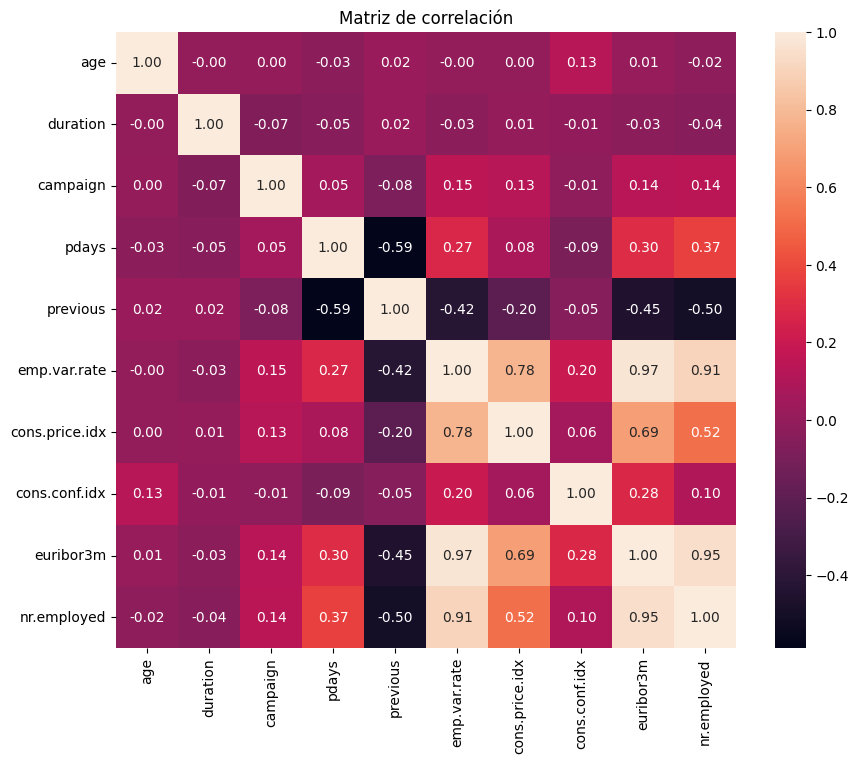

In [88]:
plt.figure(figsize=(10,8))

corr = total_data[num_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

No se observan correlaciones extremadamente altas entre la mayoría de las variables, lo que reduce el riesgo de multicolinealidad. Sin embargo, algunas variables presentan relaciones moderadas que deben ser consideradas.

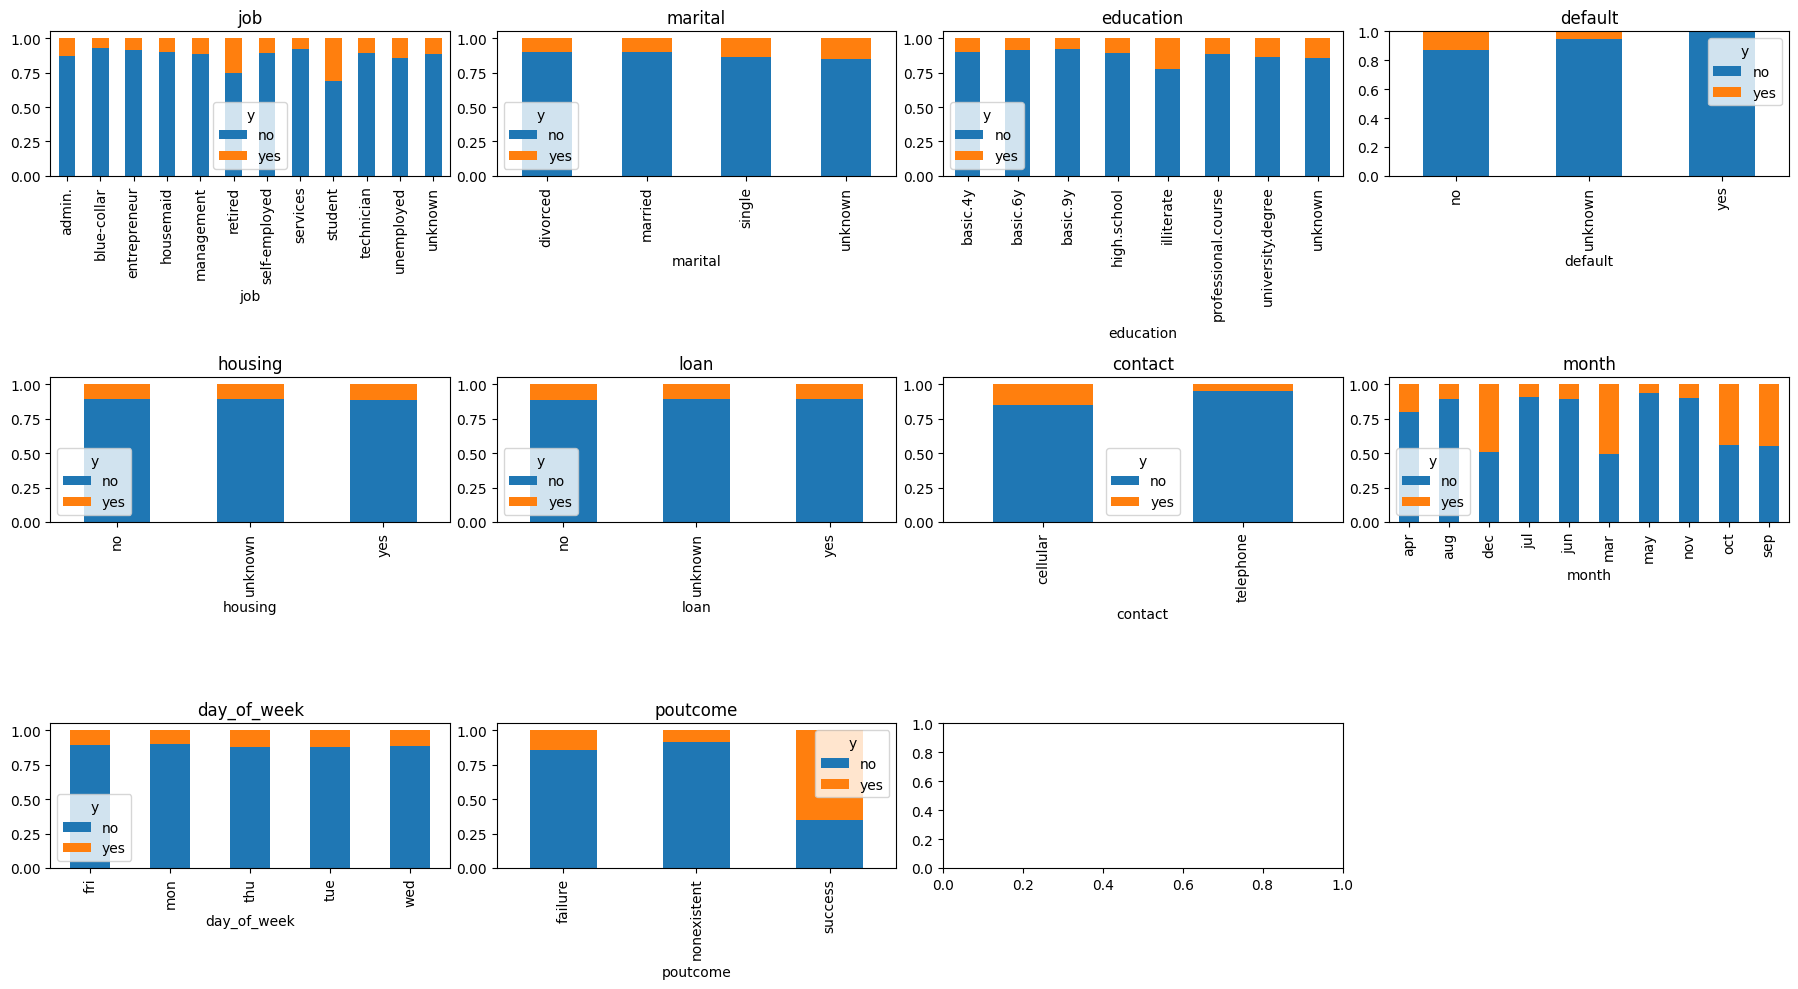

In [89]:
fig, axis = plt.subplots(3, 4, figsize=(18, 10))
axis = axis.flatten()

for i, col in enumerate(cat_cols):
    if col != "y":
        tabla = pd.crosstab(total_data[col], total_data["y"], normalize="index")
        tabla.plot(kind="bar", stacked=True, ax=axis[i])
        axis[i].set_title(col)

for j in range(i+1, len(axis)):
    fig.delaxes(axis[j])

plt.tight_layout()
plt.show()

El análisis de correlación entre variables numéricas muestra que la mayoría de las variables presentan relaciones bajas o moderadas, lo que indica que aportan información independiente al modelo.

Sin embargo, se identifican algunas correlaciones más altas entre variables de tipo económico, lo que podría generar redundancia en la información y afectar el modelo debido a multicolinealidad.

En general, no se observan correlaciones extremas que obliguen a eliminar variables de forma inmediata, pero estos resultados serán considerados en la fase de modelado.

In [90]:
data = total_data.copy()
data = data.drop("duration", axis=1)

In [91]:
data = pd.get_dummies(data, drop_first=True)

Se utilizó la técnica de One-Hot Encoding mediante la función get_dummies, con el objetivo de transformar las variables categóricas en variables numéricas. Esto permite que el modelo de machine learning pueda procesar correctamente la información sin asumir relaciones de orden entre las categorías.

In [92]:
data = data.rename(columns={"y_yes": "y"})
data.columns

Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_unknown',
       'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown',
       'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success', 'y'

Tras aplicar One-Hot Encoding, la variable objetivo fue renombrada nuevamente como y para facilitar su interpretación, representando valores binarios donde 1 indica que el cliente contrató el depósito y 0 que no lo hizo.

In [93]:
X = data.drop("y", axis=1) 
y = data["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(32950, 52)
(8238, 52)
(32950,)
(8238,)


In [95]:
X_train.to_csv("../data/processed/X_train_bank.csv", index=False)
X_test.to_csv("../data/processed/X_test_bank.csv", index=False)

y_train.to_csv("../data/processed/y_train_bank.csv", index=False)
y_test.to_csv("../data/processed/y_test_bank.csv", index=False)

In [96]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\nata1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Se configuró el parámetro max_iter en 1000 con el fin de asegurar la convergencia del modelo, evitando posibles problemas durante el proceso de entrenamiento debido a la complejidad del conjunto de datos.

In [97]:
y_pred = model.predict(X_test)

In [98]:
y_pred

array([False, False, False, ..., False, False, False], shape=(8238,))

In [99]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8977907259043457


In [100]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.91      0.99      0.94      7303
        True       0.65      0.21      0.32       935

    accuracy                           0.90      8238
   macro avg       0.78      0.60      0.63      8238
weighted avg       0.88      0.90      0.87      8238



El modelo de regresión logística presenta un alto nivel de accuracy (90%), lo que indica un buen desempeño general. Sin embargo, al analizar métricas más detalladas, se evidencia un comportamiento desigual entre las clases.

El modelo muestra una alta capacidad para predecir correctamente la clase mayoritaria (clientes que no contratan el depósito), con un recall del 99%. No obstante, presenta un desempeño limitado en la detección de la clase minoritaria (clientes que sí contratan), con un recall de solo el 21%.

Esto indica que el modelo no logra identificar adecuadamente a los clientes potenciales, lo cual es crítico para el objetivo del negocio.

Por lo tanto, se concluye que es necesario aplicar técnicas de mejora del modelo, como el ajuste de pesos de clase o métodos de balanceo, con el fin de mejorar la capacidad de predicción sobre la clase minoritaria.

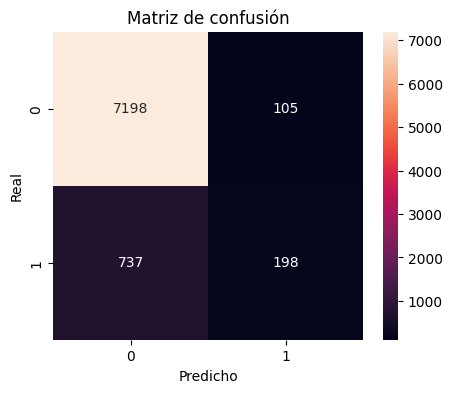

In [101]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

La matriz de confusión evidencia que el modelo tiene un alto desempeño en la identificación de clientes que no contratan el depósito, con un elevado número de verdaderos negativos (7198).

Sin embargo, se observa una cantidad considerable de falsos negativos (737), lo que indica que el modelo no logra identificar correctamente a muchos clientes que sí estarían dispuestos a contratar el producto.

Aunque el número de falsos positivos es bajo (105), lo cual es positivo desde el punto de vista de evitar contactar clientes no interesados, el objetivo del negocio se ve afectado debido a la pérdida de potenciales clientes.

En este sentido, el modelo presenta limitaciones importantes en la detección de la clase positiva, lo que sugiere la necesidad de aplicar técnicas de optimización para mejorar su capacidad predictiva.

In [102]:
model_balanced = LogisticRegression(class_weight="balanced", max_iter=1000)
model_balanced.fit(X_train, y_train)

c:\Users\nata1\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Con el fin de mejorar el rendimiento del modelo sobre la clase minoritaria, se entrenó una nueva versión utilizando el parámetro class_weight="balanced".

Esta configuración permitió mejorar la capacidad del modelo para identificar clientes que sí contratan el depósito, aumentando el recall de la clase positiva.

Sin embargo, este ajuste puede implicar una ligera disminución en la precisión global, lo cual es esperado al tratar con datos desbalanceados.

En general, el modelo optimizado resulta más útil para el objetivo del negocio, ya que prioriza la correcta identificación de clientes potenciales.

In [103]:
y_pred_balanced = model_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

       False       0.94      0.85      0.90      7303
        True       0.35      0.60      0.44       935

    accuracy                           0.83      8238
   macro avg       0.65      0.73      0.67      8238
weighted avg       0.88      0.83      0.85      8238



Tras aplicar la técnica de balanceo mediante el parámetro class_weight="balanced", se observa una mejora significativa en la capacidad del modelo para identificar clientes que sí contratan el depósito a largo plazo.

El recall de la clase positiva aumentó de forma considerable, pasando de valores bajos a un 60%, lo que indica que el modelo ahora logra detectar una mayor proporción de clientes potenciales.

Sin embargo, esta mejora viene acompañada de una disminución en la precisión y en el accuracy general, lo cual es esperado al priorizar la detección de la clase minoritaria en un conjunto de datos desbalanceado.

En términos de negocio, el modelo optimizado resulta más adecuado, ya que permite identificar un mayor número de clientes interesados, incluso a costa de contactar algunos clientes que finalmente no contratarán el producto.

In [104]:
y_prob = model_balanced.predict_proba(X_test)[:,1]

y_pred_new = (y_prob > 0.3).astype(int)

In [105]:
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

       False       0.96      0.41      0.57      7303
        True       0.16      0.86      0.27       935

    accuracy                           0.46      8238
   macro avg       0.56      0.63      0.42      8238
weighted avg       0.87      0.46      0.54      8238



En este problema, es más relevante maximizar el recall de la clase positiva, ya que el objetivo del banco es identificar la mayor cantidad posible de clientes que podrían contratar el depósito.

Aunque esto puede implicar una disminución en la precisión y un aumento en los falsos positivos, resulta más conveniente desde el punto de vista del negocio, ya que evita perder clientes potenciales.

<div style="background-color:#f9f5ff; padding:20px; border-radius:12px; border-left:6px solid #a084ca;color:#000;max-width:1300px;margin:auto;">
<p> El presente análisis tuvo como objetivo desarrollar un modelo de clasificación capaz de predecir si un cliente contratará un depósito a largo plazo, permitiendo al banco optimizar sus estrategias de marketing y enfocar sus esfuerzos en clientes con mayor probabilidad de conversión. </p> 
<p> A partir del análisis exploratorio de datos (EDA), se identificó que el conjunto de datos presenta una buena calidad, con ausencia significativa de valores nulos y una combinación de variables categóricas y numéricas relevantes. Asimismo, se evidenció un desbalance en la variable objetivo, donde la mayoría de los clientes no contratan el producto, lo cual representa un desafío importante para el modelado. </p> <p> Durante la fase de preparación de los datos, se eliminó la variable <code>duration</code> debido a que contiene información posterior al evento objetivo, evitando así la fuga de información. Posteriormente, se aplicaron técnicas de codificación para transformar las variables categóricas en variables numéricas, permitiendo su uso en modelos de machine learning. </p> <p> Se entrenó inicialmente un modelo de regresión logística, el cual mostró un alto nivel de accuracy, pero una baja capacidad para identificar correctamente a los clientes que sí contratan el depósito, evidenciado por un bajo recall en la clase positiva. Esto indicó que el modelo estaba sesgado hacia la clase mayoritaria. </p> <p> Con el fin de mejorar el desempeño, se implementó una optimización mediante el ajuste del parámetro <code>class_weight="balanced"</code>, logrando un aumento significativo en el recall de la clase positiva. Este ajuste permitió identificar un mayor número de clientes potenciales, aunque implicó una disminución en la precisión y en el accuracy general, lo cual es esperado en problemas con datos desbalanceados. </p> <p> Adicionalmente, se exploró el ajuste del umbral de decisión, lo que permitió incrementar aún más el recall; sin embargo, esta mejora se obtuvo a costa de una caída considerable en la precisión, generando un alto número de falsos positivos, lo que podría incrementar los costos operativos del banco. </p> <p> En términos de negocio, se concluye que es más relevante maximizar el <b style="color:#ff8fab;">recall</b> de la clase positiva, ya que el objetivo principal es identificar la mayor cantidad posible de clientes que podrían contratar el producto, incluso si esto implica contactar a algunos clientes que finalmente no lo harán. No obstante, es fundamental mantener un equilibrio entre recall y precisión para garantizar la eficiencia de la estrategia. </p> <p> Finalmente, el modelo optimizado con balanceo de clases representa la mejor alternativa, al ofrecer un compromiso adecuado entre la detección de clientes potenciales y el control de errores, contribuyendo así a una toma de decisiones más efectiva en campañas de marketing. </p> </div>